# What is the simplest particle that orbits in a harmonic thermophoretic trap?

**Question.** Keep the harmonic trap of `LevitationSim6x6.ipynb` ($\nabla\ln T=A\mathbf x+\mathbf G_0$). What is the smallest change to the particle's response matrices ($\mathcal R$, $\mathcal T$, $\mathbf r_H$, $I$) that produces a **stable orbit in the $x$–$y$ plane**, meaning an attracting limit cycle of finite radius?

**Answer in brief.**

1. **Every stable orbit needs two things, and no single matrix element provides both.** It needs an *energy source*, since drag only dissipates and the trap force is conservative at fixed orientation. It also needs something that fixes the orbit (radius and phase). All single-element changes to the JS-default particle, and every structured one-parameter change, decay or sit at a displaced equilibrium.
2. **Energy can be pumped in only in these ways.** With symmetric $\Gamma$ and nothing that drives the orientation, every particle comes to rest; this is proven in Section 1 and confirmed on random particles. Energy enters
   * **through a curl** in the trap force: an antisymmetric part of $\Gamma$ with a vertical axial vector;
   * **through a torque**, making the particle a *thermophoretic motor* that keeps rotating because $\Lambda_{\rm COM}\mathbf G_b$ cannot vanish. Note that a COM offset already contributes $\Lambda_{\rm COM}=[\mathbf r_H]_\times\Gamma$;
   * **through motion-driven orientation**: drag coupling $B$ turns the body as it moves, and an anisotropic $\Gamma$ turns the tilt back into force. This produces an *effective* curl (Route C).
3. **Route A, the simplest stable orbit: a rotor plus a lateral thrust (two single elements, exact).**
   * $\Lambda_{33}=\lambda$ spins the particle about the vertical at $s=\lambda g_0/\Omega_{33}$.
   * $\Gamma_{13}=t$ is a body-fixed sideways thrust $f=t\,g_0$, which therefore rotates.
   * The trap then acts as a damped oscillator driven by a rotating force, so there is a unique, globally attracting circular orbit with **no threshold**:
   $$r=\frac{t\,g_0}{\bigl|M(\omega_r^2-s^2)+iKs\bigr|},\qquad \Omega_{\rm orbit}=s .$$
   * Simulation agrees to $10^{-10}$. For the 15/15/30 µm ice ellipsoid at 0.1 Torr in a 2 Hz trap, $\lambda\approx2\times10^{-5}\,\Gamma_\perp a_3$ puts the spin on resonance, and a thrust of only $t\approx0.7\%\,\Gamma_\perp$ gives a 1 mm orbit. Both are tiny, physically plausible asymmetries.
   * Generic low-symmetry particles are motors of this kind: 400/400 random curl-free particles with full-rank $\Lambda$ never come to rest, and roughly 40% of them trace near-circular orbits.
4. **Route B, a self-excited orbit: a curl plus a compliant tilt.**
   * One pseudoscalar $c$, $\Gamma\to\Gamma+c[\hat{\mathbf e}_3]_\times$, makes the trap force swirl. Orbits grow above $c^*_0=K\sqrt{\Gamma_\perp/(M\alpha_r)}=2\zeta_r\Gamma_\perp$, but without bound, because the equations are linear at fixed orientation.
   * A small axial COM offset $h$ (the graded ellipsoid) lets the body lean. This selects the amplitude through a **supercritical Hopf bifurcation**, giving a globally attracting orbit with $r^2\propto c-c^*$. To leading order,
   $$\cos^2\theta=\frac{c^{*2}_0}{c^2}\frac{\gamma^2+c^2}{\gamma^2+c^{*2}_0},\quad \Omega_o=-\frac{c\alpha\cos\theta}{K},\quad r=\frac{\Omega_{\rm rot}\sin\theta}{hM|\Omega_o|}.$$
   * Stiff orientational locking kills it, because torque balance pushes the curl into a positive complex damping.
   * This route needs $c/\Gamma_\perp\gtrsim2\zeta_r$, which is order one except at low pressure and high trap frequency. Physically it is much harder to reach than Route A.
5. **Route C, an emergent curl: chiral drag plus axial anisotropy.** $B=b\,\mathbb I$ (helix-like) tilts the body in proportion to its displacement, $\delta\boldsymbol\theta\simeq-\Omega_{\rm rot}^{-1}B^{\mathsf T}\mathbf x$. A spheroid-like $\Gamma$ turns that tilt into a swirl, $c_{\rm eff}=Mg(1-\Gamma_\perp/\Gamma_\parallel)\,b/(\Omega_{\rm rot}\alpha)$. That is **one** new number for a library ellipsoid, and it predicts the linear threshold. With no restoring torque, however, the particle often escapes by reorienting to a stable attitude. Steady orbits appear only in a window; otherwise the particle stops or moves irregularly.
6. **All three minimal routes involve a pseudoscalar, so the particle is chiral.** A definite orbit sense needs broken mirror symmetry, unless it arises spontaneously; I did not find a spontaneous case.

The sections below derive and verify each statement. Model units follow the JS defaults ($M=1$, $K=2$, $\Omega_{\rm rot}=0.5$, $\gamma=5$, $\alpha=0.5$, $I_\perp=0.02$), in which $c^*_0=2\sqrt{10}\approx6.32$.

In [1]:
import sys, json, time
from pathlib import Path
from dataclasses import replace
import numpy as np, sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve, brentq
from IPython.display import display, Markdown, HTML
sys.path.insert(0, str(Path.cwd()))
import lev6x6 as L                       # the simulator of LevitationSim6x6.ipynb, as a module
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3, "font.size": 9, "axes.formatter.useoffset": False})
L.TEST_RESULTS.clear()
check_close, check_abs = L.check_close, L.check_abs
e3 = np.array([0, 0, 1.0])

def model_particle(c=0.0, h=0.0, K=2.0, Om=0.5, gam=5.0, gam_par=None, I=(0.02, 0.02, 0.008), B=None, Lam=None):
    """JS-default particle plus a curl c[e3]x in Gamma and a COM offset r_H = h e3 (H above COM for h > 0)."""
    G = np.diag([gam, gam, gam if gam_par is None else gam_par]) + c*L.skew(e3)
    res = L.resistance_from_blocks(L.iso3(K), L.Z3 if B is None else B, L.iso3(Om))
    return L.Particle(f"c={c:g}, h={h:g}", 1.0, np.diag(I), res, L.thermo_from_blocks(G, L.Z3 if Lam is None else Lam),
                      rH=[0, 0, h], meta=dict(length_scale=0.1))

C0 = 2.0*np.sqrt(5.0/(1.0*0.5))          # c*_0 = K sqrt(gamma/(M alpha)) for the model units

## 1. Two structural facts

**(a) Translation is linear at fixed orientation.** Suppose the tensors are constant in the body frame and $\mathbf G$ is affine. Then $M\dot{\mathbf v}=-R\,\mathcal T_{1:3}R^{\mathsf T}(A\mathbf x_H+\mathbf G_0)-(\text{drag})-Mg\hat{\mathbf e}_z$ is linear in $(\mathbf x,\mathbf v)$ for every fixed $R$. A limit cycle needs amplitude selection, and the only nonlinearity is $R(q)$ (together with the gyroscopic term). So **a stable orbit necessarily involves orientation dynamics.**

**(b) Energy can only enter through $\mathcal T$.** The mechanical energy obeys $\dot E=P_T-\mathbf U\!\cdot\!\mathcal R\mathbf U$. Drag only dissipates: its antisymmetric (gyroscopic) part does no work, and the second law makes the symmetric part positive. The thermophoretic power has a force part and a torque part:

$$P_T=\underbrace{-\mathbf v\cdot\Gamma'\,\mathbf G(\mathbf x_H)}_{\text{force channel}}\;\underbrace{-\;\boldsymbol\omega_b\cdot\Lambda_{\rm COM}\mathbf G_b}_{\text{torque channel}},\qquad \Gamma'=R\Gamma R^{\mathsf T}.$$

* **Force channel.** At fixed orientation, Stokes' theorem gives the work around a closed in-plane loop as
$$W_{\rm loop}=-\alpha_r(\Gamma'_{yx}-\Gamma'_{xy})\times(\text{signed area}).$$
This needs an antisymmetric in-plane part of $\Gamma'$, i.e. a *curl*. The simplest version is $\Gamma\to\Gamma+c[\hat{\mathbf e}_3]_\times$, which gives $\mathbf F_{\rm trap}=-\alpha_r(\gamma\mathbf x+c\,\hat{\mathbf e}_z\times\mathbf x)$.
* **Torque channel.** A particle whose thermophoretic torque cannot vanish in any orientation keeps rotating, powered by $-\boldsymbol\omega\cdot\Lambda\mathbf G_b$: it is a thermophoretic *motor*. The simplest version is $\Lambda_{33}=\lambda$, which spins the body about the gradient axis. Rotation alone does not move the COM. It needs a converter, such as a body-fixed force component that then rotates with the body.

* **Motion-driven orientation.** Without any torque source, no drag coupling and no offset, $\boldsymbol\omega$ simply decays and the orientation freezes. The fixed-orientation result then applies, and **every particle with symmetric $\Gamma$ comes to rest**. This is a theorem, not a numerical observation. A drag coupling $B$ or an offset breaks it: the orientation is then slaved to the motion, which can make the force effectively non-reciprocal.

$c$, $\lambda$ and an isotropic $B=b\,\mathbb I$ are all pseudoscalars (chirality) in the body frame.

The following sections check these claims numerically before building the minimal model.

## 2. Numerical scans

### 2.1 Every single matrix element, one at a time

Starting from the JS-default particle, each element of $\Gamma$, $\Lambda$, the symmetric pairs of $\mathcal R$, and $\mathbf r_H$ is changed on its own. Each run starts slightly off-centre and runs for 300 time units. The run is classified as *decays*, *static offset*, *orbit*, *irregular* or *unbounded*.

In [2]:
base = L.from_legacy_js(L.LEGACY_JS_CONFIG); base.meta["length_scale"] = 0.1

def classify(p, t_end=300.0, r_blow=1e4):
    env = L.make_environment(p); rhs = L.make_rhs(p, env)
    s0 = np.concatenate([L.initial_state(-p.rH + [0.01, 0.005, 0], [0, 0, 0], [0, 0, 0]), [0, 0]])
    ev = lambda t, s: np.hypot(s[0], s[1]) - r_blow; ev.terminal = True
    sol = solve_ivp(rhs, (0, t_end), s0, method="LSODA", rtol=1e-8, atol=1e-10, events=ev, dense_output=True)
    if sol.status == 1: return "unbounded", np.nan
    S = sol.sol(np.linspace(0.75*t_end, t_end, 600))
    r, speed, Lz = np.hypot(S[0], S[1]), np.hypot(S[3], S[4]), S[0]*S[4] - S[1]*S[3]
    if speed.mean() < 1e-6: return ("decays" if r.mean() < 1e-4 else "static offset"), r.mean()
    if r.std() < 0.02*r.mean() and abs(np.mean(np.sign(Lz))) > 0.99: return "ORBIT", r.mean()
    return "irregular (bounded)", r.mean()

rows = []
for blk, name in [(0, "Gamma"), (3, "Lambda")]:
    for i in range(3):
        for j in range(3):
            for v in ([-20, -8, 8, 20] if blk == 0 else [-0.2, -0.08, 0.08, 0.2]):
                th = base.thermo.copy(); th[blk + i, j] += v
                rows.append((f"{name}[{i+1}{j+1}] += {v:g}", *classify(replace(base, thermo=th))))
for i in range(6):
    for j in range(i + 1, 6):
        for v in (-0.6, 0.6):
            r6 = base.res.copy(); r6[i, j] = r6[j, i] = v*np.sqrt(r6[i, i]*r6[j, j])
            rows.append((f"Res[{i+1}{j+1}] = Res[{j+1}{i+1}] (corr {v:+})", *classify(replace(base, res=r6))))
for k in range(3):
    for v in (-0.05, 0.05):
        rh = np.zeros(3); rh[k] = v; rows.append((f"rH[{k+1}] = {v:+}", *classify(replace(base, rH=rh))))
kinds = {}
for _, k, _ in rows: kinds[k] = kinds.get(k, 0) + 1
display(Markdown(f"**{len(rows)} single-element changes:** " + ", ".join(f"{v} × {k}" for k, v in kinds.items())))
display(Markdown("| change | outcome | final r |\n|---|---|---|\n" + "\n".join(f"| {a} | {b} | {c:.4g} |" for a, b, c in rows if b != "decays")))
check_abs("no single matrix element produces an orbit", sum(k == "ORBIT" for _, k, _ in rows), 0, 0)

**108 single-element changes:** 4 × unbounded, 96 × decays, 8 × static offset

| change | outcome | final r |
|---|---|---|
| Gamma[11] += -20 | unbounded | nan |
| Gamma[11] += -8 | unbounded | nan |
| Gamma[13] += -20 | static offset | 15.7 |
| Gamma[13] += -8 | static offset | 6.278 |
| Gamma[13] += 8 | static offset | 6.278 |
| Gamma[13] += 20 | static offset | 15.7 |
| Gamma[22] += -20 | unbounded | nan |
| Gamma[22] += -8 | unbounded | nan |
| Gamma[23] += -20 | static offset | 15.7 |
| Gamma[23] += -8 | static offset | 6.278 |
| Gamma[23] += 8 | static offset | 6.278 |
| Gamma[23] += 20 | static offset | 15.7 |

PASS  no single matrix element produces an orbit
      got 0   expected 0   abs. err 0.00e+00


None of them orbits. The non-decaying cases are trivial: a negative diagonal $\Gamma_{ii}$ anti-confines, and $\Gamma_{13},\Gamma_{23}$ act as a constant body-frame *thrust*, $F_x=\Gamma_{13}g_0$, which only moves the equilibrium ($r^*=\Gamma_{13}g_0/(\Gamma_{11}\alpha)$). A single $\Gamma_{12}$ is not a curl either. It makes the stiffness matrix triangular, with real eigenvalues $\gamma,\gamma$, so nothing rotates. A curl needs the **antisymmetric pair**, which is one physical parameter.

### 2.2 One-parameter *structured* changes, alone and combined with the curl

In [3]:
def run_change(c=0.0, **kw):
    th = kw.pop("thermo", base.thermo).copy(); th[:3] += c*L.skew(e3)
    return classify(L.Particle("x", base.mass, base.inertia, kw.get("res", base.res), th,
                               rH=kw.get("rH", np.zeros(3)), meta=base.meta))
changes = {}
for k, e in enumerate(np.eye(3), 1):
    th = base.thermo.copy(); th[3:] += 0.05*L.skew(e); changes[f"polar Λ = 0.05 [e{k}]×"] = dict(thermo=th)
th = base.thermo.copy(); th[3:] += 0.5*L.skew(e3); changes["polar Λ = 0.5 [e3]× (strong)"] = dict(thermo=th)
th = base.thermo.copy(); th[3:] += 0.3*np.eye(3); changes["chiral Λ = 0.3·1"] = dict(thermo=th)
th = base.thermo.copy(); th[5, 2] += 0.3; changes["spin drive Λ33 = 0.3"] = dict(thermo=th)
changes["B = 0.3·1 (chiral drag)"] = dict(res=L.resistance_from_blocks(L.iso3(2.0), L.iso3(0.3), L.iso3(0.5)))
changes["B = 0.3 [e3]× (polar drag coupling)"] = dict(res=L.resistance_from_blocks(L.iso3(2.0), 0.3*L.skew(e3), L.iso3(0.5)))
changes["B = 0.3 e3e3ᵀ"] = dict(res=L.resistance_from_blocks(L.iso3(2.0), 0.3*np.outer(e3, e3), L.iso3(0.5)))
for h in (0.01, -0.01): changes[f"COM offset rH = {h:+} e3"] = dict(rH=h*e3)
th = base.thermo.copy(); th[2, 2] = 10.0; changes["Γ33/Γ11 = 2"] = dict(thermo=th)
tab = [("curl c = 10 [e3]× only", *run_change(10.0), "—")]
for name, kw in changes.items():
    tab.append((name, *run_change(0.0, **dict(kw)), run_change(10.0, **dict(kw))[0]))
display(Markdown("| change | alone | final r | together with curl c = 10 |\n|---|---|---|---|\n" +
                 "\n".join(f"| {a} | {b} | {c:.3g} | {d} |" for a, b, c, d in tab)))

| change | alone | final r | together with curl c = 10 |
|---|---|---|---|
| curl c = 10 [e3]× only | unbounded | nan | — |
| polar Λ = 0.05 [e1]× | decays | 2.47e-20 | unbounded |
| polar Λ = 0.05 [e2]× | decays | 3.27e-19 | unbounded |
| polar Λ = 0.05 [e3]× | decays | 1.68e-39 | ORBIT |
| polar Λ = 0.5 [e3]× (strong) | decays | 3.06e-99 | decays |
| chiral Λ = 0.3·1 | decays | 2.35e-15 | irregular (bounded) |
| spin drive Λ33 = 0.3 | decays | 2.1e-102 | unbounded |
| B = 0.3·1 (chiral drag) | decays | 8.37e-12 | irregular (bounded) |
| B = 0.3 [e3]× (polar drag coupling) | decays | 3.48e-14 | ORBIT |
| B = 0.3 e3e3ᵀ | decays | 2.39e-18 | unbounded |
| COM offset rH = +0.01 e3 | decays | 6.36e-18 | ORBIT |
| COM offset rH = -0.01 e3 | decays | 6.98e-15 | ORBIT |
| Γ33/Γ11 = 2 | decays | 2.39e-18 | unbounded |

The pattern is clear for the **curl** (force-channel) route:

* **Nothing orbits on its own.** Every structured one-parameter change decays, and the curl alone runs away.
* **The curl plus one compliant orientation coupling does orbit.** Examples are an axial COM offset (with either sign: a top-heavy particle flips over and orbits the other way), the polar drag coupling $B=b[\hat{\mathbf e}_3]_\times$, or a *weak* polar alignment torque.
* **Strong locking** (large polar $\Lambda$) and couplings that do not tilt the body in response to its motion (spin drive, $B\propto\hat{\mathbf e}_3\hat{\mathbf e}_3^{\mathsf T}$, anisotropy alone) do not.
* **Isotropic chiral couplings give bounded but irregular motion**, which is left for later study.

### 2.3 Randomised check: which random particles keep moving?

The particles below have random positive-definite $\mathcal R$ (with a full coupling block $B$), random symmetric positive $\Gamma$, a random COM offset and random inertia. There are three groups:

* **(i)** no curl, no torque source and no coupling: $\Lambda=0$, $\mathbf r_H=0$, $B=0$, but anisotropic $\Gamma$ and random $K,\Omega,I$;
* **(ii)** as (i), but with a random drag coupling $B$;
* **(iii)** no curl, with random $\Lambda$, $\mathbf r_H$ and $B$ (fully generic);
* **(iv)** as (iii), with a random curl added.

The cell runs 40 particles per group; a separate run of 400 particles in group (iii) gave 400/400 sustained motion.

In [4]:
rng = np.random.default_rng(7)
def rand_particle(antisym=0.0, lam_scale=0.1, offset=0.05, coupling=True):
    while True:
        Q = L.quat_to_R(L.normalize_q(rng.normal(size=4))); I = Q @ np.diag(rng.uniform(0.005, 0.03, 3)) @ Q.T
        A = np.diag(np.sqrt([2, 2, 2, 0.5, 0.5, 0.5])) @ (np.eye(6) + 0.35*rng.normal(size=(6, 6)))
        S = rng.normal(size=(3, 3)); G = 5*(np.eye(3) + 0.25*(S + S.T)/2)
        if np.linalg.eigvalsh(G).min() > 0.5: break
    R6 = A @ A.T + 0.05*np.eye(6)
    if not coupling: R6[:3, 3:] = 0; R6[3:, :3] = 0
    return L.Particle("rand", 1.0, I, R6,
                      L.thermo_from_blocks(G + antisym*L.skew(rng.normal(size=3)), lam_scale*rng.normal(size=(3, 3))),
                      rH=offset*rng.normal(size=3), meta=dict(length_scale=0.1))
def fate(p, t_end=300.0):
    env = L.make_environment(p); rhs = L.make_rhs(p, env)
    s0 = np.concatenate([L.initial_state(-p.rH + [0.02, 0.01, 0], [0, 0, 0], [0, 0, 0]), [0, 0]])
    ev = lambda t, s: np.linalg.norm(s[0:3]) - 1e4; ev.terminal = True
    sol = solve_ivp(rhs, (0, t_end), s0, method="LSODA", rtol=1e-8, atol=1e-10, events=ev, dense_output=True)
    if sol.status == 1: return "unbounded", np.nan
    S = sol.sol(np.linspace(0.8*t_end, t_end, 400)); sp_ = np.linalg.norm(S[3:6], axis=0)
    if sp_.max() < 1e-7: return "at rest", np.nan
    if sp_.min() < 1e-4: return "slowly decaying", np.nan
    rr = np.linalg.norm(S[0:2] - S[0:2].mean(1, keepdims=True), axis=0)
    return "sustained motion", rr.std()/rr.mean()
t0 = time.time(); tally, circ = {}, {}
groups = [("(i) no curl, no torque source, no coupling", dict(lam_scale=0.0, offset=0.0, coupling=False)),
          ("(ii) as (i) + random drag coupling B", dict(lam_scale=0.0, offset=0.0)),
          ("(iii) generic: random Λ, offset, B (no curl)", dict()),
          ("(iv) generic + random curl", dict(antisym=4.0))]
for label, kw in groups:
    out = [fate(rand_particle(**kw)) for _ in range(40)]
    tally[label] = {k: [o[0] for o in out].count(k) for k in sorted({o[0] for o in out})}
    circ[label] = np.array([o[1] for o in out if o[0] == "sustained motion"])
display(Markdown("| group | outcomes (40 random particles) | sustained cases with near-circular orbits (radius spread < 5%) |\n|---|---|---|\n" +
                 "\n".join(f"| {k} | {v} | {int(np.sum(circ[k] < 0.05))} / {len(circ[k])} |" for k, v in tally.items())))
print(f"({time.time() - t0:.0f} s)")
check_abs("(i) no curl, no torque source, no coupling: every particle comes to rest", 40 - tally[groups[0][0]].get("at rest", 0), 0, 0)
check_close("(iii) generic curl-free particles are motors (fraction sustained > 0.8)", float(tally[groups[2][0]].get("sustained motion", 0)/40 > 0.8), 1.0, 0)

| group | outcomes (40 random particles) | sustained cases with near-circular orbits (radius spread < 5%) |
|---|---|---|
| (i) no curl, no torque source, no coupling | {'at rest': 40} | 0 / 0 |
| (ii) as (i) + random drag coupling B | {'at rest': 29, 'slowly decaying': 4, 'sustained motion': 7} | 1 / 7 |
| (iii) generic: random Λ, offset, B (no curl) | {'sustained motion': 40} | 17 / 40 |
| (iv) generic + random curl | {'sustained motion': 39, 'unbounded': 1} | 14 / 39 |

(309 s)
PASS  (i) no curl, no torque source, no coupling: every particle comes to rest
      got 0   expected 0   abs. err 0.00e+00
PASS  (iii) generic curl-free particles are motors (fraction sustained > 0.8)
      got 1.   expected 1.   rel. err 0.00e+00


As the theorem predicts, group (i) always comes to rest. Adding only a drag coupling $B$ (group ii) already lets some particles keep moving; this is Route C, below. A generic particle (group iii) almost never stops: a full-rank $\Lambda_{\rm COM}$, which includes the offset term $[\mathbf r_H]_\times\Gamma$, leaves no torque-free orientation, so the particle becomes a motor. About 40% of these motors trace near-circular in-plane orbits; the rest move quasi-periodically. The simplest version of the motor mechanism is Route A.

## 3. Route A: a thermophoretic rotor with a lateral thrust (the simplest stable orbit)

Start from the JS-default particle and change **two single elements**:

* $\Lambda_{33}=\lambda$. The vertical background gradient $\mathbf G_b=-g_0\hat{\mathbf e}_3$ exerts the axial torque $\lambda g_0$, so the body spins about the vertical at $s=\lambda g_0/\Omega_{33}$ and stays upright.
* $\Gamma_{13}=t$. The same gradient pushes sideways along the body axis $\hat{\mathbf e}_1$ with $f=t\,g_0$. This thrust co-rotates with the body.

The COM then obeys exactly

$$M\ddot\xi+K\dot\xi+M\omega_r^2\xi=f\,e^{i(st+\phi_0)}
\quad\Longrightarrow\quad
\xi(t)\to\frac{f}{M(\omega_r^2-s^2)+iKs}\,e^{i(st+\phi_0)} .$$

This is a damped linear oscillator driven by a rotating force, so every trajectory converges to one circle of radius $|f/(M(\omega_r^2-s^2)+iKs)|$. The orbit runs at the spin rate, in the spin's sense, and resonates when $s=\omega_r$, where $r_{\max}=f/(K\omega_r)$. There is no threshold and no nonlinearity is needed. Neither element works alone: $\lambda$ alone spins the particle in place, and $t$ alone only displaces it.

In [5]:
def rotor(lam, t, **kw):
    th = base.thermo.copy(); th[5, 2] += lam; th[0, 2] += t
    return L.Particle(f"rotor λ={lam:g}, t={t:g}", 1.0, base.inertia, base.res, th, meta=base.meta)
def rotor_prediction(p, env):
    g0 = np.linalg.norm(env.G0); s_ = p.thermo[5, 2]*g0/p.res[5, 5]; f = p.thermo[0, 2]*g0
    return f/abs(p.mass*(p.thermo[0, 0]*env.A[0, 0]/p.mass - s_**2) + 1j*p.res[0, 0]*s_), s_
rows_ = []
for lam, t in [(0.3, 2.0), (0.6, 2.0), (0.3, 0.5), (-0.3, 2.0)]:
    p = rotor(lam, t); env = L.make_environment(p)
    tr = L.nd_simulate(p, env, L.initial_state([0.5, 0, 0], [0, 0, 0], [0, 0, 0]), 60.0, frames=6001, rtol=1e-10, atol=1e-12)
    late = tr.s[-2000:]; r = np.hypot(late[:, 0], late[:, 1])
    W = np.polyfit(tr.t[-2000:], np.unwrap(np.arctan2(late[:, 1], late[:, 0])), 1)[0]
    r_pred, s_pred = rotor_prediction(p, env)
    rows_.append((lam, t, r.mean(), r_pred, W, s_pred, max(L.tilt_deg(q) for q in tr.s[:, 6:10])))
    check_close(f"rotor λ={lam}, t={t}: radius = forced-oscillator formula", r.mean(), r_pred, 1e-8)
    check_close(f"rotor λ={lam}, t={t}: orbit frequency = spin rate", W, s_pred, 1e-6)
display(Markdown("| λ = Λ33 | t = Γ13 | r (sim) | r (formula) | Ω_orbit (sim) | spin s (formula) | max tilt (deg) |\n|---|---|---|---|---|---|---|\n" +
                 "\n".join("| " + " | ".join(f"{v:.6g}" for v in row) + " |" for row in rows_)))
rotor_example = rotor(0.3, 2.0)

PASS  rotor λ=0.3, t=2.0: radius = forced-oscillator formula
      got 1.50648756   expected 1.50648756   rel. err 1.97e-09
PASS  rotor λ=0.3, t=2.0: orbit frequency = spin rate
      got 1.1772   expected 1.1772   rel. err 9.48e-10
PASS  rotor λ=0.6, t=2.0: radius = forced-oscillator formula
      got 0.69989057   expected 0.69989057   rel. err 5.01e-09
PASS  rotor λ=0.6, t=2.0: orbit frequency = spin rate
      got 2.3544   expected 2.3544   rel. err 2.07e-09


PASS  rotor λ=0.3, t=0.5: radius = forced-oscillator formula
      got 0.37662189   expected 0.37662189   rel. err 1.97e-09
PASS  rotor λ=0.3, t=0.5: orbit frequency = spin rate
      got 1.1772   expected 1.1772   rel. err 9.53e-10
PASS  rotor λ=-0.3, t=2.0: radius = forced-oscillator formula
      got 1.50648756   expected 1.50648756   rel. err 1.94e-09
PASS  rotor λ=-0.3, t=2.0: orbit frequency = spin rate
      got -1.1772   expected -1.1772   rel. err 8.80e-10


| λ = Λ33 | t = Γ13 | r (sim) | r (formula) | Ω_orbit (sim) | spin s (formula) | max tilt (deg) |
|---|---|---|---|---|---|---|
| 0.3 | 2 | 1.50649 | 1.50649 | 1.1772 | 1.1772 | 0 |
| 0.6 | 2 | 0.699891 | 0.699891 | 2.3544 | 2.3544 | 0 |
| 0.3 | 0.5 | 0.376622 | 0.376622 | 1.1772 | 1.1772 | 0 |
| -0.3 | 2 | 1.50649 | 1.50649 | -1.1772 | -1.1772 | 0 |

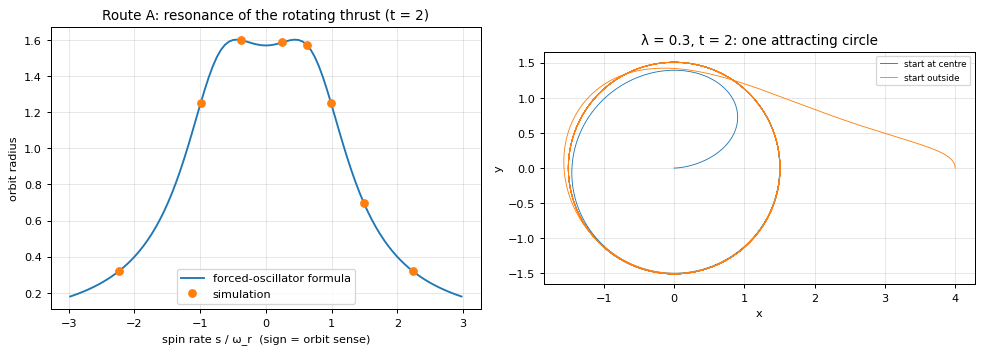

In [6]:
lams = np.linspace(-1.2, 1.2, 97); r_th = [rotor_prediction(rotor(l, 2.0), L.make_environment(rotor(l, 2.0)))[0] for l in lams]
lam_s = [-0.9, -0.4, -0.15, 0.1, 0.25, 0.4, 0.6, 0.9]; r_sim = []
for l in lam_s:
    p = rotor(l, 2.0); tr = L.nd_simulate(p, L.make_environment(p), L.initial_state([0, 0, 0], [0, 0, 0], [0, 0, 0]), 50.0, frames=2001, rtol=1e-9, atol=1e-11)
    r_sim.append(np.hypot(tr.s[-400:, 0], tr.s[-400:, 1]).mean())
p = rotor_example; env_r = L.make_environment(p)
tr_in = L.nd_simulate(p, env_r, L.initial_state([0, 0, 0], [0, 0, 0], [0, 0, 0]), 30.0, frames=3001, rtol=1e-10, atol=1e-12)
tr_out = L.nd_simulate(p, env_r, L.initial_state([4.0, 0, 0], [0, 1.0, 0], [0, 0, 0]), 30.0, frames=3001, rtol=1e-10, atol=1e-12)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(lams*1.962/0.5/np.sqrt(2.5), r_th, label="forced-oscillator formula"); ax[0].plot(np.array(lam_s)*1.962/0.5/np.sqrt(2.5), r_sim, "o", label="simulation")
ax[0].set(xlabel="spin rate s / ω_r  (sign = orbit sense)", ylabel="orbit radius", title="Route A: resonance of the rotating thrust (t = 2)"); ax[0].legend()
ax[1].plot(tr_in.s[:, 0], tr_in.s[:, 1], lw=0.7, label="start at centre"); ax[1].plot(tr_out.s[:, 0], tr_out.s[:, 1], lw=0.7, label="start outside")
ax[1].set_aspect("equal"); ax[1].set(title="λ = 0.3, t = 2: one attracting circle", xlabel="x", ylabel="y"); ax[1].legend(fontsize=7)
fig.tight_layout(); plt.show()

### 3.1 Route C: an emergent curl from chiral drag plus anisotropy

Set $\mathbf r_H=0$, $\Lambda=0$, and give the body a helix-like drag coupling $B=b\,\mathbb I$ together with a spheroid-like $\Gamma={\rm diag}(\Gamma_\perp,\Gamma_\perp,\Gamma_\parallel)$. The mechanism is a loop:

* Moving at $\mathbf v$ exerts the drag torque $-B^{\mathsf T}\mathbf v$. With fast rotational relaxation the body turns at $\boldsymbol\omega\simeq-\Omega^{-1}B^{\mathsf T}\mathbf v$, so the tilt tracks the displacement, $\delta\boldsymbol\theta\simeq-(b/\Omega)\,\mathbf x$.
* The tilted anisotropic body feels the sideways force $g_0(\Gamma_\parallel-\Gamma_\perp)\,\delta\boldsymbol\theta\times\hat{\mathbf e}_z$.
* Together these give an in-plane swirl $\propto\hat{\mathbf e}_z\times\mathbf x$, and the coupling also lowers the drag:

$$c_{\rm eff}=\frac{Mg\,(1-\Gamma_\perp/\Gamma_\parallel)\,b}{\Omega_{\rm rot}\,\alpha},\qquad K_{\rm eff}=K-\frac{b^2}{\Omega_{\rm rot}}\quad\Longrightarrow\quad\text{instability if }|c_{\rm eff}|>K_{\rm eff}\sqrt{\Gamma_\perp/(M\alpha)} .$$

For a library ellipsoid this is a *single* new parameter, $b$. The prediction is compared below with the full Jacobian, and one steady orbit is shown. Nothing restores the orientation, though, so above threshold the particle often reorients to an attitude where $c_{\rm eff}$ vanishes, and stops.

| Γ∥ (Γ⊥ = 5) | threshold b (quasi-static formula) | threshold b (full Jacobian) |
|---|---|---|
| 2.5 | 0.1572 | 0.1521 |
| 4 | 0.4899 | 0.4798 |
| 7 | 0.4499 | 0.4398 |
| 10 | 0.2944 | 0.2860 |
| 20 | 0.2058 | 0.1993 |

PASS  Route C: effective-curl threshold vs full Jacobian (within 5%)
      got [0.15719359 0.48994563 0.4499225  0.29441155 0.20579979]   expected [0.15207933 0.47983238 0.43982528 0.28596674 0.19933817]   rel. err 2.46e-02
PASS  Route C example (b = 0.2, Γ∥ = 2.5): steady orbit
      got True   expected 1.   rel. err 0.00e+00


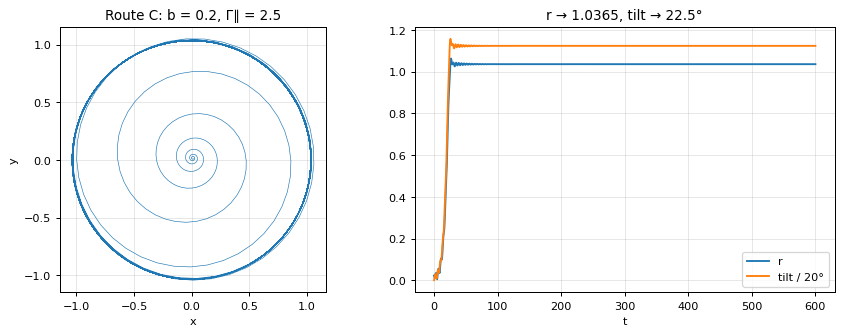

In [7]:
def helix(b, gpar, gperp=5.0):
    return L.Particle(f"helix b={b:g}, Γ∥={gpar:g}", 1.0, np.diag([0.02, 0.02, 0.008]), L.resistance_from_blocks(L.iso3(2.0), b*np.eye(3), L.iso3(0.5)),
                      L.thermo_from_blocks(np.diag([gperp, gperp, gpar]), L.Z3), meta=dict(length_scale=0.1))
def b_pred(gpar, gperp=5.0):
    return brentq(lambda b: abs(9.81*(1 - gperp/gpar)*b/(0.5*0.5)) - (2.0 - b**2/0.5)*np.sqrt(gperp/0.5), 1e-6, 0.99)
def b_jac(gpar):
    f = lambda b: L.sorted_eigs(L.linearize(helix(b, gpar), L.make_environment(helix(b, gpar)), [0, 0, 0], [1, 0, 0, 0])).real.max() - 1e-9
    return brentq(f, 1e-3, 0.99)
rows_ = [(gp, b_pred(gp), b_jac(gp)) for gp in (2.5, 4.0, 7.0, 10.0, 20.0)]
display(Markdown("| Γ∥ (Γ⊥ = 5) | threshold b (quasi-static formula) | threshold b (full Jacobian) |\n|---|---|---|\n" +
                 "\n".join(f"| {a:g} | {b_:.4f} | {c:.4f} |" for a, b_, c in rows_)))
check_close("Route C: effective-curl threshold vs full Jacobian (within 5%)", [r[1] for r in rows_], [r[2] for r in rows_], 0.05)
p = helix(0.2, 2.5); trC = L.nd_simulate(p, L.make_environment(p), L.initial_state([0.02, 0.01, 0], [0, 0, 0], [0, 0, 0]), 600.0, frames=6001, rtol=1e-9, atol=1e-11)
rC = np.hypot(trC.s[-1200:, 0], trC.s[-1200:, 1])
check_close("Route C example (b = 0.2, Γ∥ = 2.5): steady orbit", rC.std()/rC.mean() < 1e-4, 1.0, 0)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(trC.s[:, 0], trC.s[:, 1], lw=0.5); ax[0].set_aspect("equal"); ax[0].set(title="Route C: b = 0.2, Γ∥ = 2.5", xlabel="x", ylabel="y")
ax[1].plot(trC.t, np.hypot(trC.s[:, 0], trC.s[:, 1]), label="r"); ax[1].plot(trC.t, [L.tilt_deg(q)/20 for q in trC.s[:, 6:10]], label="tilt / 20°")
ax[1].set(xlabel="t", title=f"r → {rC.mean():.4f}, tilt → {L.tilt_deg(trC.s[-1, 6:10]):.1f}°"); ax[1].legend(); fig.tight_layout(); plt.show()

## 4. Route B, ingredient 1: the curl alone gives a linear Hopf instability

Take $\Gamma=\gamma\mathbb I+c[\hat{\mathbf e}_3]_\times$ with $\mathbf r_H=0$, and write $\xi=x+iy$. Since $\hat{\mathbf e}_z\times\mathbf x\leftrightarrow i\xi$, the in-plane motion is

$$M\ddot\xi+K\dot\xi+\alpha(\gamma+ic)\,\xi=0 .$$

Setting $\xi\propto e^{i\omega t}$ on the stability boundary gives $M\omega^2=\alpha\gamma$ and $K\omega=-\alpha c$. So a **clockwise** orbit (for $c>0$) at the trap frequency $\omega_r$ starts to grow when

$$|c|>c^*_0=K\sqrt{\frac{\gamma}{M\alpha}}=\frac{K}{M\omega_r}\,\gamma=2\zeta_r\,\gamma ,$$

where $\zeta_r$ is the damping ratio of the radial trap mode. The drive has to beat the damping. The system is linear, though, so above threshold the orbit grows **without bound**.

PASS  growth rate: full Jacobian vs formula (c in [0, 3c*])
      got [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.89786650e-16 3.52505350e-02 6.96119355e-02 1.03138172e-01
 1.35878768e-01 1.67879196e-01 1.99181241e-01 2.29823349e-01
 2.59840934e-01 2.89266664e-01 3.18130719e-01 3.46461019e-01
 3.74283435e-01 4.01621975e-01 4.28498951e-01 4.54935131e-01
 4.80949874e-01 5.06561253e-01 5.31786160e-01 5.56640411e-01
 5.81138830e-01 6.05295331e-01 6.29122990e-01 6.52634111e-01
 6.75840288e-01 6.98752452e-01 7.21380928e-01 7.43735475e-01
 7.65825328e-01 7.87659234e-01 8.09245488e-01 8.30591963e-01
 8.51706138e-01 8.72595125e-01 8.93265693e-01 9.13724288e-01
 9.33977056e-01 9.54029862e-01 9.73888304e-01 9.93557732e-01
 1.01304326e+00

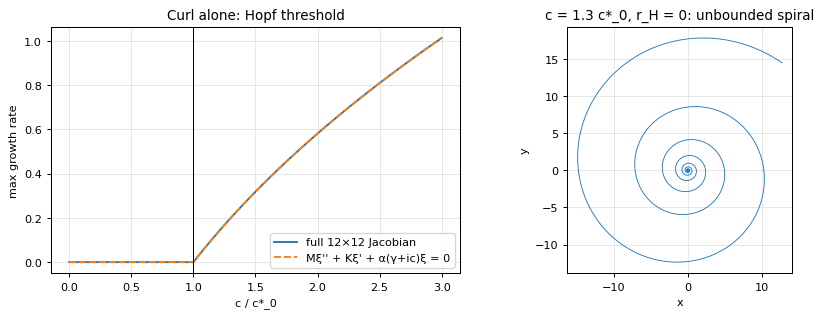

In [8]:
cs = np.linspace(0, 3*C0, 61)
growth_full = [L.sorted_eigs(L.linearize(model_particle(c), L.make_environment(model_particle(c)), [0, 0, 0], [1, 0, 0, 0])).real.max() for c in cs]
growth_formula = [max(np.roots([1.0, 2.0, 0.5*(5 + 1j*c)]).real.max(), 0) for c in cs]
check_close("growth rate: full Jacobian vs formula (c in [0, 3c*])", np.maximum(growth_full, 0), growth_formula, 1e-8)
c_thr = brentq(lambda c: np.roots([1.0, 2.0, 0.5*(5 + 1j*c)]).real.max(), 1, 20)
check_close("threshold c*_0 = K sqrt(gamma/(M alpha))", c_thr, C0, 1e-10)

p = model_particle(1.3*C0); tr = L.nd_simulate(p, L.make_environment(p), L.initial_state([0.01, 0, 0], [0, 0, 0], [0, 0, 0]), 40.0, frames=2001, rtol=1e-9, atol=1e-12)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(cs/C0, growth_full, label="full 12×12 Jacobian"); ax[0].plot(cs/C0, growth_formula, "--", label="Mξ'' + Kξ' + α(γ+ic)ξ = 0")
ax[0].axvline(1, color="k", lw=0.8); ax[0].set(xlabel="c / c*_0", ylabel="max growth rate", title="Curl alone: Hopf threshold"); ax[0].legend()
ax[1].plot(tr.s[:, 0], tr.s[:, 1], lw=0.7); ax[1].set_aspect("equal"); ax[1].set(title="c = 1.3 c*_0, r_H = 0: unbounded spiral", xlabel="x", ylabel="y")
fig.tight_layout(); plt.show()

## 5. Route B, ingredient 2: an axial COM offset. Exact reduced linear theory

Put the force centre a distance $h$ above the COM ($\mathbf r_H=h\hat{\mathbf e}_3$). Let the tilt of the axis be the small horizontal vector $\boldsymbol\theta$, written as $\varphi=\theta_x+i\theta_y$. All forces except gravity act at H. With $\xi_H=\xi+h\varphi$ and $g_0=Mg/\Gamma_\parallel$, the in-plane dynamics reduce to two complex degrees of freedom:

$$M\ddot\xi=F,\qquad I_\perp\ddot\varphi=hF-hMg\,\varphi-\Omega_{\rm rot}\dot\varphi,$$
$$F=-\alpha(\Gamma_\perp+ic)\,\xi_H+g_0\bigl(\Gamma_\parallel-\Gamma_\perp-ic\bigr)\varphi-K\dot\xi_H .$$

The term $g_0(\Gamma_\parallel-\Gamma_\perp)\varphi$ is the sideways force of a tilted anisotropic body. The term $-ic\,g_0\varphi$ is the curl acting on the tilted background gradient. The cell below derives the quartic characteristic polynomial and checks it against the full Jacobian.

In [9]:
s, M_, K_, Om_, I_, al_, Gp, Ga, c_, h_, g_ = sp.symbols("s M K Omega_rot I_perp alpha Gamma_perp Gamma_par c h g")
xi, ph = sp.symbols("xi varphi")
F = -al_*(Gp + sp.I*c_)*(xi + h_*ph) + (M_*g_/Ga)*(Ga - Gp - sp.I*c_)*ph - K_*s*(xi + h_*ph)
eqs = [M_*s**2*xi - F, I_*s**2*ph - (h_*F - h_*M_*g_*ph - Om_*s*ph)]
P = sp.expand(sp.Matrix([[sp.diff(e, v) for v in (xi, ph)] for e in eqs]).det())
display(Markdown("**Characteristic polynomial (one circular polarisation; the other has $c\\to-c$):**"))
display(sp.collect(P, s))
display(Markdown("**h = 0 factorises:**"))
display(sp.factor(P.subs(h_, 0)))
P_num = sp.lambdify((c_, h_, M_, K_, Om_, I_, al_, Gp, Ga, g_), sp.Poly(P, s).all_coeffs())

def reduced_eigs(c, h, M=1.0, K=2.0, Om=0.5, I=0.02, al=0.5, Gp=5.0, Ga=5.0, g=9.81):
    return np.concatenate([np.roots(np.array(P_num(sg*c, h, M, K, Om, I, al, Gp, Ga, g), dtype=complex)) for sg in (1, -1)])
for cv, hv in [(10.0, 0.01), (7.0, 0.003), (15.0, 0.1)]:
    pp = model_particle(cv, hv); J = L.linearize(pp, L.make_environment(pp), -pp.rH, [1, 0, 0, 0])
    full = np.linalg.eigvals(J); red = reduced_eigs(cv, hv)
    # every reduced root must appear among the full eigenvalues (the rest are the decoupled z and axial-spin modes)
    err = max(np.min(np.abs(full - z)) for z in red)
    check_abs(f"reduced quartic reproduces the full Jacobian (c={cv}, h={hv})", err, 0, 1e-8)

**Characteristic polynomial (one circular polarisation; the other has $c\to-c$):**

Gamma_perp*M*alpha*g*h + I_perp*M*s**4 + I*M*alpha*c*g*h + s**3*(I_perp*K + K*M*h**2 + M*Omega_rot) + s**2*(Gamma_perp*I_perp*alpha + Gamma_perp*M*alpha*h**2 + I*I_perp*alpha*c + K*Omega_rot + I*M*alpha*c*h**2 + Gamma_perp*M**2*g*h/Gamma_par + I*M**2*c*g*h/Gamma_par) + s*(Gamma_perp*Omega_rot*alpha + K*M*g*h + I*Omega_rot*alpha*c)

**h = 0 factorises:**

s*(I_perp*s + Omega_rot)*(Gamma_perp*alpha + K*s + M*s**2 + I*alpha*c)

PASS  reduced quartic reproduces the full Jacobian (c=10.0, h=0.01)
      got 3.19918138e-14   expected 0   abs. err 3.20e-14
PASS  reduced quartic reproduces the full Jacobian (c=7.0, h=0.003)
      got 4.26613964e-14   expected 0   abs. err 4.27e-14
PASS  reduced quartic reproduces the full Jacobian (c=15.0, h=0.1)
      got 2.34485831e-14   expected 0   abs. err 2.34e-14


### 5.1 Strong locking kills the orbit

Let the tilt be fast and overdamped ($I_\perp,\Omega_{\rm rot}\to0$). Torque balance then forces $F=Mg\,\varphi$: the total force at H must point along the body axis. Eliminating $\varphi$ to leading order in $h$ gives

$$M\ddot\xi+\frac{K\,\Gamma_\parallel}{\Gamma_\perp+ic}\,\dot\xi+\alpha\Gamma_\parallel\,\xi=0 .$$

The curl has moved out of the stiffness and into a complex damping, whose real part $K\Gamma_\parallel\Gamma_\perp/(\Gamma_\perp^2+c^2)$ is **positive for every $c$**. A stiff bottom-heavy particle therefore never orbits, which is why the library's strongly graded ellipsoid is stable. The instability survives only when the orientation is compliant.

In [10]:
# check: with I, Omega -> 0 the reduced quartic tends to the "locked" quadratic, which is always stable
qs = np.array(P_num(10.0, 1e-3, 1.0, 2.0, 1e-9, 1e-12, 0.5, 5.0, 5.0, 9.81), dtype=complex)
locked = np.roots([1.0, 2.0*5/(5 + 10j), 0.5*5])
r_all = np.roots(qs); slow = r_all[np.argsort(np.abs(r_all))][:2]
check_close("locked limit: slow roots match M s^2 + K Gpar/(Gperp+ic) s + alpha Gpar = 0", np.sort_complex(slow), np.sort_complex(locked), 1e-3)
check_close("locked limit is stable although c = 10 > c*_0", float(max(r.real for r in slow) < 0), 1.0, 0)

PASS  locked limit: slow roots match M s^2 + K Gpar/(Gperp+ic) s + alpha Gpar = 0
      got [-0.24916163+2.01891216j -0.15056315-1.21933296j]   expected [-0.24940116+2.0193951j -0.15059884-1.2193951j]   rel. err 2.29e-04
PASS  locked limit is stable although c = 10 > c*_0
      got 1.   expected 1.   rel. err 0.00e+00


### 5.2 Stability map

Two unstable modes appear. At **small $h$** the unstable mode is the *orbital* mode, near the trap frequency, and its threshold rises smoothly from $c^*_0$. At **large $h$ and large $c$** the curl destabilises the fast tilt-pendulum *wobble* mode instead. In between, near $h\approx0.03$–$0.1$, the tilt is locked and nothing is unstable.

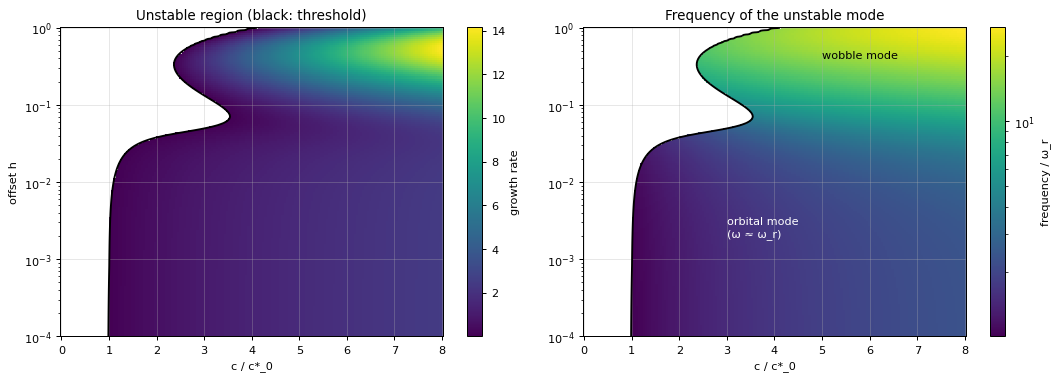

In [11]:
hs = np.logspace(-4, 0, 150); cgrid = np.linspace(0, 8*C0, 180)
Gr = np.zeros((len(hs), len(cgrid))); Wf = np.zeros_like(Gr)
for i, hv in enumerate(hs):
    for j, cv in enumerate(cgrid):
        ev = reduced_eigs(cv, hv); k = np.argmax(ev.real); Gr[i, j], Wf[i, j] = ev[k].real, abs(ev[k].imag)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
m = ax[0].pcolormesh(cgrid/C0, hs, np.where(Gr > 0, Gr, np.nan), shading="auto"); ax[0].contour(cgrid/C0, hs, Gr, [0], colors="k")
plt.colorbar(m, ax=ax[0], label="growth rate"); ax[0].set(yscale="log", xlabel="c / c*_0", ylabel="offset h", title="Unstable region (black: threshold)")
m = ax[1].pcolormesh(cgrid/C0, hs, np.where(Gr > 0, Wf/np.sqrt(2.5), np.nan), shading="auto", norm=plt.matplotlib.colors.LogNorm())
ax[1].contour(cgrid/C0, hs, Gr, [0], colors="k"); plt.colorbar(m, ax=ax[1], label="frequency / ω_r")
ax[1].text(3, 2e-3, "orbital mode\n(ω ≈ ω_r)", color="w"); ax[1].text(5, 0.4, "wobble mode", color="k")
ax[1].set(yscale="log", xlabel="c / c*_0", title="Frequency of the unstable mode"); fig.tight_layout(); plt.show()

## 6. Route B: the self-excited limit cycle

### 6.1 Simulation: one attracting circle

Take $c=10\approx1.58\,c^*_0$ and $h=0.01$. Trajectories started inside the orbit (near the centre) and outside it (at three times the radius, tilted and moving) converge to the **same** circle. The energy budget shows the thermophoretic work and the dissipation growing at equal rates once the cycle is reached.

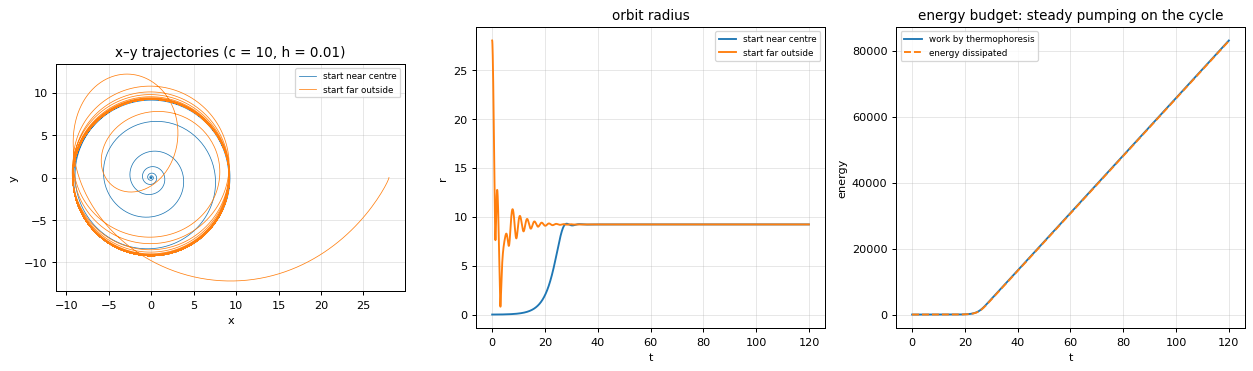

PASS  inner and outer starts reach the same radius
      got 9.21291533   expected 9.21291544   rel. err 1.13e-08


In [12]:
pc = model_particle(10.0, 0.01); env_c = L.make_environment(pc)
runs = {"start near centre": L.initial_state(-pc.rH + [0.01, 0, 0], [0, 0, 0], [0, 0, 0]),
        "start far outside": L.initial_state(-pc.rH + [28.0, 0, 0], [0, -3.0, 0], [0.5, 0, 0], tilt=20)}
trs = {k: L.nd_simulate(pc, env_c, s0, 120.0, frames=6001, rtol=1e-9, atol=1e-11) for k, s0 in runs.items()}
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
for k, tr in trs.items():
    ax[0].plot(tr.s[:, 0], tr.s[:, 1], lw=0.6, label=k); ax[1].plot(tr.t, np.hypot(tr.s[:, 0], tr.s[:, 1]), label=k)
ax[0].set_aspect("equal"); ax[0].set(title="x–y trajectories (c = 10, h = 0.01)", xlabel="x", ylabel="y"); ax[0].legend(fontsize=7)
ax[1].set(title="orbit radius", xlabel="t", ylabel="r"); ax[1].legend(fontsize=7)
d = L.trajectory_diagnostics(trs["start near centre"])
ax[2].plot(d["t"], d["WT"], label="work by thermophoresis"); ax[2].plot(d["t"], d["WD"], "--", label="energy dissipated")
ax[2].set(title="energy budget: steady pumping on the cycle", xlabel="t", ylabel="energy"); ax[2].legend(fontsize=7)
fig.tight_layout(); plt.show()
r_end = {k: np.hypot(tr.s[-1000:, 0], tr.s[-1000:, 1]).mean() for k, tr in trs.items()}
check_close("inner and outer starts reach the same radius", r_end["start far outside"], r_end["start near centre"], 1e-6)

### 6.2 The orbit as a relative equilibrium

In a frame rotating with the orbit, the axisymmetric particle is at rest. It has COM at $(r,0,z)$, velocity $\Omega_o r\,\hat{\mathbf t}$, axis tilted by $\theta$ toward azimuth $\psi$ (measured from the radial direction), and angular velocity $\boldsymbol\omega=\Omega_o\hat{\mathbf e}_z+s\,\hat{\mathbf e}_3$. That leaves six unknowns $(r,z,\theta,\psi,\Omega_o,s)$ and six equations. The linear acceleration must equal the centripetal one, and the angular acceleration must equal $\Omega_o\hat{\mathbf e}_z\times\boldsymbol\omega$. Solving them with the full model's right-hand side gives the limit cycle exactly and fast.

In [13]:
def orbit_state(u):
    r, z, th, psi, W, spin = u
    ax3 = np.array([np.sin(th)*np.cos(psi), np.sin(th)*np.sin(psi), np.cos(th)])
    n = np.cross(e3, ax3); nn = np.linalg.norm(n)
    q = np.array([1.0, 0, 0, 0]) if nn < 1e-14 else L.axis_angle_q(n/nn, np.degrees(th))
    R = L.quat_to_R(q); w_lab = W*e3 + spin*ax3
    return np.concatenate([[r, 0, z], [0, W*r, 0], q, R.T @ w_lab]), R, w_lab

def asymptotic_orbit(c, h, M=1.0, K=2.0, Om=0.5, gam=5.0, al=0.5):
    cs2 = K**2*gam/(M*al); th = np.arccos(np.sqrt(cs2/c**2*(gam**2 + c**2)/(gam**2 + cs2)))
    W = -c*al*np.cos(th)/K; r = Om*np.sin(th)/(h*M*abs(W))
    return dict(r=r, z=-c*r*np.sin(th)/gam, theta=th, W=W)

def solve_orbit(p, env, guess):
    rhs = L.make_rhs(p, env)
    def res(u):
        st, R, w_lab = orbit_state(u); d = rhs(0, np.concatenate([st, [0, 0]]))
        return np.concatenate([d[3:6] + [u[4]**2*u[0], 0, 0], R @ d[10:13] - np.cross(u[4]*e3, w_lab)])
    u, info, ier, msg = fsolve(res, guess, full_output=True, xtol=1e-13)
    return u, (ier == 1 and np.abs(res(u)).max() < 1e-9)

def model_orbit(c, h, guess=None, **kw):
    p = model_particle(c, h, **kw); env = L.make_environment(p)
    if guess is None:
        a = asymptotic_orbit(c, h); guess = [a["r"], a["z"], a["theta"], -np.sign(c)*np.pi/2, a["W"], -a["W"]*np.cos(a["theta"])]
    return solve_orbit(p, env, guess)

u10, ok = model_orbit(10.0, 0.01)
check_close("relative equilibrium matches the simulated radius", abs(u10[0]), r_end["start near centre"], 1e-6)
display(Markdown(f"Exact orbit (c = 10, h = 0.01): r = {abs(u10[0]):.5f}, z = {u10[1]:.4f}, tilt = {np.degrees(u10[2]):.3f}°, "
                 f"lean azimuth ψ = {np.degrees(u10[3]):.2f}° from radial, Ω_o = {u10[4]:.4f} (clockwise), spin about axis = {u10[5]:.4f}. "
                 "The axis leans (to within ≈ 5°) along the direction of motion, and the particle spins about its own axis "
                 "so that ω·e3 ≈ 0, i.e. it does not spin relative to its own axis direction."))

PASS  relative equilibrium matches the simulated radius
      got 9.21291582   expected 9.21291544   rel. err 4.19e-08


Exact orbit (c = 10, h = 0.01): r = 9.21292, z = -7.6992, tilt = 24.668°, lean azimuth ψ = -90.27° from radial, Ω_o = -2.2651 (clockwise), spin about axis = 2.0584. The axis leans (to within ≈ 5°) along the direction of motion, and the particle spins about its own axis so that ω·e3 ≈ 0, i.e. it does not spin relative to its own axis direction.

### 6.3 Bifurcation diagram: a supercritical Hopf

Continuing the relative equilibrium in $c$ for several $h$ shows that the orbit branch leaves $r=0$ **exactly at the linear threshold $c^*(h)$**, with $r^2\propto c-c^*$. At strong drive the lean approaches 90°: the body lies on its side and the radius shrinks again.

PASS  r -> 0 as c -> c*(h) (smallest computed r, h = 0.01)
      got 0.08811987   expected 0   abs. err 8.81e-02


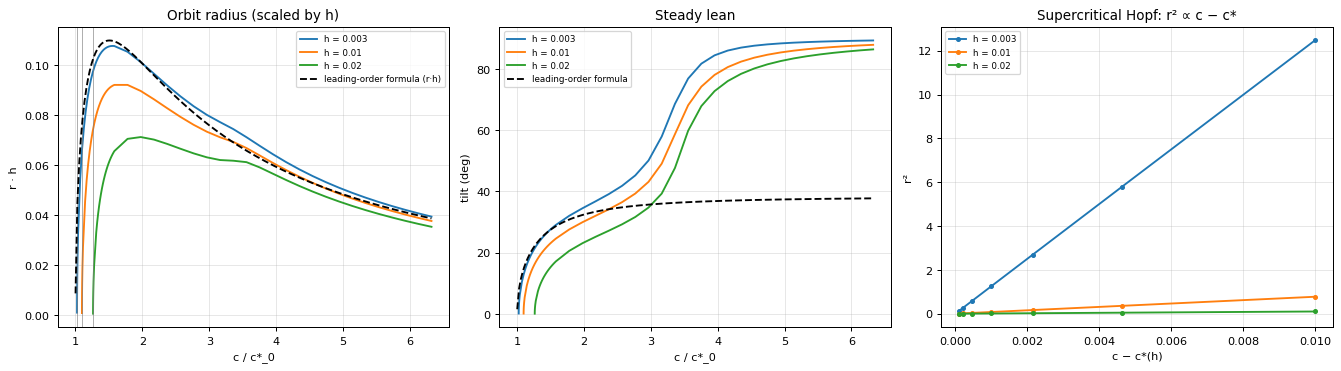

h = 0.01: c*(h) = 6.93474 (c*_0 = 6.32456); r^2/(c - c*) = 77.35


In [14]:
def threshold(h): return brentq(lambda c: reduced_eigs(c, h).real.max(), C0*0.999, 3*C0)
def branch(h, c_hi=40.0):
    c_st = threshold(h); u, _ = model_orbit(10.0, h); out = []
    for cs_ in (np.linspace(10, c_hi, 25), np.concatenate([np.linspace(10, c_st + 0.3, 20), c_st + np.logspace(-1, -4, 10)])):
        uu = u
        for cv in cs_:
            uu, ok = model_orbit(cv, h, guess=uu)
            if not ok or abs(uu[0]) < 1e-7: break
            out.append((cv, abs(uu[0]), np.degrees(uu[2]), uu[4], uu[1]))
    return c_st, np.array(sorted(out))
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for hv in (0.003, 0.01, 0.02):
    c_st, B = branch(hv)
    ax[0].plot(B[:, 0]/C0, B[:, 1]*hv, label=f"h = {hv}"); ax[0].axvline(c_st/C0, color="gray", lw=0.5)
    ax[1].plot(B[:, 0]/C0, B[:, 2], label=f"h = {hv}")
    near = B[:, 0] < c_st + 0.02
    ax[2].plot(B[near, 0] - c_st, B[near, 1]**2, "o-", ms=3, label=f"h = {hv}")
    if hv == 0.01:
        slope = np.polyfit(B[near, 0] - c_st, B[near, 1]**2, 1)[0]
        check_abs("r -> 0 as c -> c*(h) (smallest computed r, h = 0.01)", B[:, 1].min(), 0, 0.2)
ca = np.linspace(C0*1.001, 40, 200); asy = [asymptotic_orbit(cv, 1.0) for cv in ca]
ax[0].plot(ca/C0, [a["r"] for a in asy], "k--", label="leading-order formula (r·h)")
ax[1].plot(ca/C0, [np.degrees(a["theta"]) for a in asy], "k--", label="leading-order formula")
ax[0].set(xlabel="c / c*_0", ylabel="r · h", title="Orbit radius (scaled by h)"); ax[0].legend(fontsize=7)
ax[1].set(xlabel="c / c*_0", ylabel="tilt (deg)", title="Steady lean"); ax[1].legend(fontsize=7)
ax[2].set(xlabel="c − c*(h)", ylabel="r²", title="Supercritical Hopf: r² ∝ c − c*"); ax[2].legend(fontsize=7)
fig.tight_layout(); plt.show()
print(f"h = 0.01: c*(h) = {threshold(0.01):.5f} (c*_0 = {C0:.5f}); r^2/(c - c*) = {slope:.2f}")

### 6.4 Leading-order theory of the saturated orbit

The limit $h\to0$ and $I_\perp\to0$ can be worked out by hand. On the orbit the axis tip leans by $\theta$, almost exactly along the direction of motion ($\psi\approx\mp90°$).

* **Tangential force:** the thermophoretic swirl, reduced to $c\cos\theta$ because the pseudovector is tilted, balances drag: $\Omega_o=-c\alpha\cos\theta/K$.
* **Vertical force:** the tilted swirl also has a vertical component, $c\alpha r\sin\theta$, which is balanced by the trap after the particle sinks by $z^*\simeq-c r\sin\theta/\gamma$. The tilted axis then feeds this vertical gradient back into the horizontal plane, adding $c^2\alpha\sin^2\theta/\gamma$ to the radial stiffness: $M\Omega_o^2=\gamma\alpha+c^2\alpha\sin^2\theta/\gamma$.
* **Torque:** the vertical component of the torque from the centripetal force at H, $hM\Omega_o^2 r\sin\theta$, keeps the tilted axis precessing against rotational drag, $\Omega_{\rm rot}\Omega_o\sin^2\theta$.

Together these give the formulas in the summary. **Range of validity:** the formulas assume a moderate lean and track the exact branch for $c\lesssim2.5\,c^*_0$ (Section 6.3). At stronger drive the exact lean climbs toward 90° as the body rolls onto its side, while the formula saturates near 38°; the radius formula $r\cdot h$ stays within about 10%. Within that range the formulas are exact at leading order; the $O(h)$ correction $cMg\sin\theta/(\gamma r)$ in the radial balance, and the gyroscopic terms $\propto I_\perp\Omega_o^2$, account for the remaining few per cent.

In [15]:
rows_ = []
for hv, Iv in [(1e-2, 0.02), (1e-3, 0.02), (1e-3, 2e-4), (1e-4, 2e-4)]:
    u, ok = model_orbit(10.0, hv, I=(Iv, Iv, 0.4*Iv)); a = asymptotic_orbit(10.0, hv)
    rows_.append((hv, Iv, abs(u[0])*hv, a["r"]*hv, np.degrees(u[2]), np.degrees(a["theta"]), u[4], a["W"], u[1]/abs(u[0]), a["z"]/a["r"]))
display(Markdown("| h | I⊥ | r·h exact | r·h formula | tilt exact | tilt formula | Ω_o exact | Ω_o formula | z/r exact | z/r formula |\n|---|---|---|---|---|---|---|---|---|---|\n" +
                 "\n".join("| " + " | ".join(f"{v:.4g}" for v in row) + " |" for row in rows_)))
check_close("leading-order r·h within 2% when h, I are small", rows_[-1][2], rows_[-1][3], 0.02)
check_close("leading-order orbit frequency within 0.5%", rows_[-1][6], rows_[-1][7], 5e-3)

| h | I⊥ | r·h exact | r·h formula | tilt exact | tilt formula | Ω_o exact | Ω_o formula | z/r exact | z/r formula |
|---|---|---|---|---|---|---|---|---|---|
| 0.01 | 0.02 | 0.09213 | 0.1095 | 24.67 | 28.71 | -2.265 | -2.193 | -0.8357 | -0.9608 |
| 0.001 | 0.02 | 0.1119 | 0.1095 | 30.33 | 28.71 | -2.263 | -2.193 | -1.007 | -0.9608 |
| 0.001 | 0.0002 | 0.1075 | 0.1095 | 28.15 | 28.71 | -2.194 | -2.193 | -0.9435 | -0.9608 |
| 0.0001 | 0.0002 | 0.1094 | 0.1095 | 28.67 | 28.71 | -2.193 | -2.193 | -0.9596 | -0.9608 |

PASS  leading-order r·h within 2% when h, I are small
      got 0.10937559   expected 0.10954451   rel. err 1.54e-03
PASS  leading-order orbit frequency within 0.5%
      got -2.1932986   expected -2.19264505   rel. err 2.98e-04


### 6.5 Stability of the orbit, and absence of hysteresis

These are direct tests. Start from the exact orbit perturbed in radius (×0.3 and ×2) and in orientation (random quaternion noise), and also from the centre: every run returns to the same cycle. Below threshold, a particle launched on a large orbit decays, so the bifurcation is not subcritical.

In [16]:
def final_radius(c, h, s0, t_end):
    p = model_particle(c, h); sol = solve_ivp(L.make_rhs(p, L.make_environment(p)), (0, t_end), np.concatenate([s0, [0, 0]]),
                                              method="LSODA", rtol=1e-9, atol=1e-11, dense_output=True)
    S = sol.sol(np.linspace(0.9*t_end, t_end, 200)); return np.hypot(S[0], S[1]).mean()
rng2 = np.random.default_rng(3); rows_ = []
for cv, T in [(7.2, 3000.0), (10.0, 600.0), (26.0, 600.0)]:
    u, ok = model_orbit(cv, 0.01); s_orb, _, _ = orbit_state(u); finals = []
    for scale in (0.3, 2.0):
        s0 = s_orb.copy(); s0[0:2] *= scale; s0[3:5] *= scale; s0[6:10] = L.normalize_q(s0[6:10] + 0.05*rng2.normal(size=4)); finals.append(final_radius(cv, 0.01, s0, T))
    finals.append(final_radius(cv, 0.01, L.initial_state([0.01, 0, -0.01], [0, 0, 0], [0, 0, 0]), T))
    rows_.append((cv, abs(u[0]), *finals))
    check_close(f"c = {cv}: all perturbed starts return to the orbit", finals, [abs(u[0])]*3, 1e-5)
display(Markdown("| c | exact r | from 0.3× (+noise) | from 2× (+noise) | from centre |\n|---|---|---|---|---|\n" +
                 "\n".join("| " + " | ".join(f"{v:.6g}" for v in row) + " |" for row in rows_)))
u72, _ = model_orbit(7.2, 0.01); s72, _, _ = orbit_state(u72)
r_below = final_radius(6.85, 0.01, s72, 3000.0)
check_abs(f"below threshold (c = 6.85 < c* = {threshold(0.01):.3f}) a large orbit decays: no hysteresis", r_below, 0, 1e-6)

PASS  c = 7.2: all perturbed starts return to the orbit
      got [4.3112348  4.31123477 4.31123495]   expected [4.31123791 4.31123791 4.31123791]   rel. err 7.12e-07


PASS  c = 10.0: all perturbed starts return to the orbit
      got [9.21291379 9.21291378 9.21291389]   expected [9.21291582 9.21291582 9.21291582]   rel. err 2.18e-07


PASS  c = 26.0: all perturbed starts return to the orbit
      got [5.86270672 5.86270675 5.86270672]   expected [5.86270946 5.86270946 5.86270946]   rel. err 4.66e-07


| c | exact r | from 0.3× (+noise) | from 2× (+noise) | from centre |
|---|---|---|---|---|
| 7.2 | 4.31124 | 4.31123 | 4.31123 | 4.31123 |
| 10 | 9.21292 | 9.21291 | 9.21291 | 9.21291 |
| 26 | 5.86271 | 5.86271 | 5.86271 | 5.86271 |

PASS  below threshold (c = 6.85 < c* = 6.935) a large orbit decays: no hysteresis
      got 1.44868082e-09   expected 0   abs. err 1.45e-09


### 6.6 Animation of the limit cycle

The animation shows $c=10$, $h=0.01$, starting near the centre: the orbit grows, the body leans forward along its velocity, and it settles onto the circle.

In [17]:
# enlarge the drawn body (drawing only) so the lean is visible at the scale of the orbit
viz = replace(trs["start near centre"], particle=replace(pc, shape={"type": "cylinder", "half_length": 1.6, "radius": 0.55},
                                                           meta={**pc.meta, "length_scale": 1.6}))
L.show_animation(viz, n_frames=70, elev=22, azim=-60)

## 7. Physical units

### 7.1 Route B: a chiral, slightly graded ice ellipsoid

This section uses the library's 15/15/30 µm ice ellipsoid in air at 260 K. The curl is written as $c=\kappa_c\,\Gamma_\perp$, and $h$ is a small axial COM offset. The linear threshold does not depend on $h$ as $h\to0$:

$$\frac{c^*_0}{\Gamma_\perp}=\frac{K_\perp}{M\omega_r}=2\zeta_r .$$

The required chirality is set by the damping ratio of the radial trap mode. At low pressure $K$ falls roughly in proportion to $p$ (Epstein regime) while $\Gamma$ stays constant (free-molecular thermophoresis), so orbits get dramatically easier as the pressure drops or the trap stiffens.

In [18]:
def chiral_offset(p, kappa_c, h):
    th = p.thermo.copy(); th[:3] += kappa_c*p.thermo[0, 0]*L.skew(e3)
    I0 = p.inertia + p.mass*p.rH[2]**2*np.diag([1, 1, 0])
    return replace(p, name=f"{p.name}, c = {kappa_c:.3g} Γ⊥, h = {h*1e9:.3g} nm", thermo=th, rH=h*e3, inertia=I0 - p.mass*h**2*np.diag([1, 1, 0]))
rows_ = []
for p_torr in (1.0, 0.3, 0.1):
    ell = L.ellipsoid_particle([15e-6, 15e-6, 30e-6], gas=L.gas_properties(260.0, p_torr))
    for fr in (2.0, 5.0):
        wr = 2*np.pi*fr
        rows_.append((p_torr, fr, ell.res[0, 0]/(2*ell.mass*wr), ell.res[0, 0]/(ell.mass*wr), ell.mass/ell.res[0, 0], ell.inertia[0, 0]/ell.res[3, 3]))
display(Markdown("| p (Torr) | f_r (Hz) | ζ_r | required c*/Γ⊥ = 2ζ_r | M/K (s) | I⊥/Ω (s) |\n|---|---|---|---|---|---|\n" +
                 "\n".join("| " + " | ".join(f"{v:.3g}" for v in row) + " |" for row in rows_)))

| p (Torr) | f_r (Hz) | ζ_r | required c*/Γ⊥ = 2ζ_r | M/K (s) | I⊥/Ω (s) |
|---|---|---|---|---|---|
| 1 | 2 | 2.26 | 4.52 | 0.0176 | 0.02 |
| 1 | 5 | 0.904 | 1.81 | 0.0176 | 0.02 |
| 0.3 | 2 | 0.761 | 1.52 | 0.0523 | 0.0635 |
| 0.3 | 5 | 0.304 | 0.609 | 0.0523 | 0.0635 |
| 0.1 | 2 | 0.262 | 0.523 | 0.152 | 0.188 |
| 0.1 | 5 | 0.105 | 0.209 | 0.152 | 0.188 |

At 0.1 Torr with a 2 Hz radial trap ($c^*_0\approx0.52\,\Gamma_\perp$), we simulate $c=1.5\,c^*_0$ for several offsets. One difference from the model-unit study matters. For real micro-particles the rotational relaxation time $I_\perp/\Omega_{\rm rot}$ is *comparable to or longer than* the translational one, whereas the model units had it 12 times shorter. The orbital and wobble modes then merge, and the saturated state is a particle **rolling almost on its side** around the trap, not gently leaning.

In [19]:
gas01 = L.gas_properties(260.0, 0.1); ell = L.ellipsoid_particle([15e-6, 15e-6, 30e-6], gas=gas01)
fr = 2.0; wr = 2*np.pi*fr; kc0 = ell.res[0, 0]/(ell.mass*wr)
phys_runs = {}
rows_ = []
for h in (1e-8, 3e-8, 1e-7):
    p = chiral_offset(ell, 1.5*kc0, h); env = L.make_environment(p, alpha=L.alpha_from_trap_frequencies(p, fr, 3*fr))
    J = L.linearize(p, env, -p.rH, [1, 0, 0, 0]); lam = L.sorted_eigs(J); lam = lam[np.argmax(lam.real)]
    tr = L.nd_simulate(p, env, L.initial_state(-p.rH + [1e-6, 0, 0], [0, 0, 0], [0, 0, 0]), 30.0, frames=3001, rtol=1e-8, atol=1e-9)
    phys_runs[h] = tr
    late = tr.s[-800:]; r = np.hypot(late[:, 0], late[:, 1]); tilt = np.array([L.tilt_deg(q) for q in late[:, 6:10]])
    W = np.polyfit(tr.t[-800:], np.unwrap(np.arctan2(late[:, 1], late[:, 0])), 1)[0]
    rows_.append((h*1e9, lam.real, abs(lam.imag)/wr, 1e3*r.mean(), r.std()/r.mean(), tilt.mean(), W/wr, 1e3*late[:, 2].mean()))
display(Markdown("| h (nm) | linear growth (1/s) | unstable-mode freq / ω_r | orbit r (mm) | r spread | tilt (deg) | orbit Ω / ω_r | height z (mm) |\n|---|---|---|---|---|---|---|---|\n" +
                 "\n".join("| " + " | ".join(f"{v:.4g}" for v in row) + " |" for row in rows_)))
check_abs("physical particle: the 10 nm offset case reaches a steady orbit", rows_[0][4], 0, 1e-4)

| h (nm) | linear growth (1/s) | unstable-mode freq / ω_r | orbit r (mm) | r spread | tilt (deg) | orbit Ω / ω_r | height z (mm) |
|---|---|---|---|---|---|---|---|
| 10 | 6.041 | 2.09 | 1.779 | 1.696e-07 | 84.45 | -5.362 | 0.7404 |
| 30 | 11.29 | 3.434 | 0.2061 | 3.742e-07 | 88 | -15.42 | 0.8599 |
| 100 | 22.55 | 6.125 | 0.01865 | 3.189e-07 | 89.4 | -1.148 | 0.8744 |

PASS  physical particle: the 10 nm offset case reaches a steady orbit
      got 1.69565189e-07   expected 0   abs. err 1.70e-07


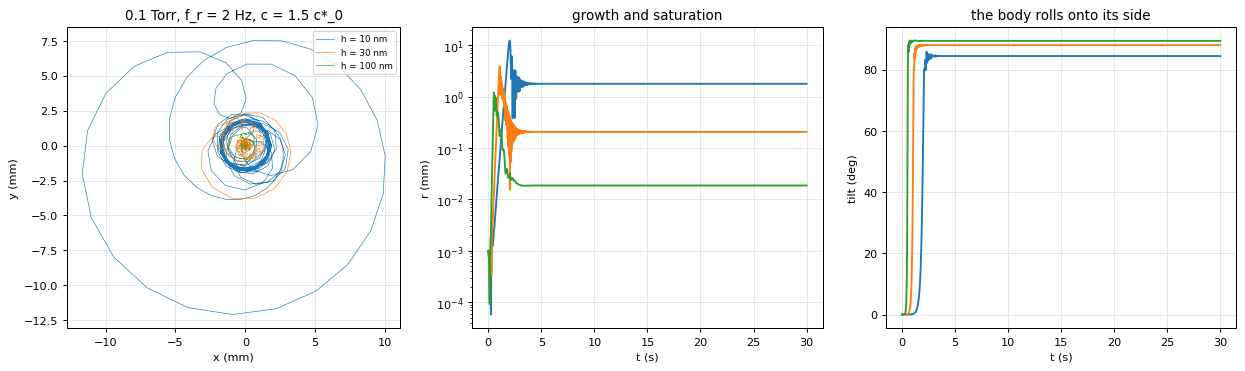

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
for h, tr in phys_runs.items():
    ax[0].plot(1e3*tr.s[:, 0], 1e3*tr.s[:, 1], lw=0.5, label=f"h = {h*1e9:g} nm")
    ax[1].semilogy(tr.t, 1e3*np.hypot(tr.s[:, 0], tr.s[:, 1]), label=f"h = {h*1e9:g} nm")
    ax[2].plot(tr.t, [L.tilt_deg(q) for q in tr.s[:, 6:10]], label=f"h = {h*1e9:g} nm")
ax[0].set_aspect("equal"); ax[0].set(xlabel="x (mm)", ylabel="y (mm)", title="0.1 Torr, f_r = 2 Hz, c = 1.5 c*_0"); ax[0].legend(fontsize=7)
ax[1].set(xlabel="t (s)", ylabel="r (mm)", title="growth and saturation"); ax[2].set(xlabel="t (s)", ylabel="tilt (deg)", title="the body rolls onto its side")
fig.tight_layout(); plt.show()

**Is $c\sim\Gamma_\perp$ plausible?** The table says that at 1 Torr the chiral part of $\Gamma$ must *exceed* the ordinary thermophoretic coefficient several times over. Chirality-induced transverse thermophoresis in a real particle is almost certainly a small fraction of $\Gamma$. The practical route is therefore to reduce $\zeta_r=K/(2M\omega_r)$ with low pressure and a stiff radial trap, so that a modest chiral asymmetry $c/\Gamma_\perp\sim0.1$ is enough. A realistic estimate of $c$ for a given particle shape needs the free-molecular surface integrals mentioned as the next step in `LevitationSim6x6.ipynb`.

### 7.2 Route A in physical units

For the same 15/15/30 µm ice ellipsoid, the cell computes the spin torque coefficient that puts the rotor on resonance ($s=\omega_r$) and the thrust needed for a 1 mm orbit, then simulates both. Rotational drag is tiny at low pressure, so the required chirality is minute.

In [21]:
rows_ = []
for p_torr in (1.0, 0.1):
    ell = L.ellipsoid_particle([15e-6, 15e-6, 30e-6], gas=L.gas_properties(260.0, p_torr)); fr = 2.0; wr = 2*np.pi*fr
    env0 = L.make_environment(ell, alpha=L.alpha_from_trap_frequencies(ell, fr, 3*fr)); g0 = np.linalg.norm(env0.G0)
    Gp, a3, K, M = ell.thermo[0, 0], 30e-6, ell.res[0, 0], ell.mass
    lam = ell.res[5, 5]*wr/g0; t_rel = 1e-3/(g0*Gp/(K*wr))
    th = ell.thermo.copy(); th[5, 2] += lam; th[0, 2] += t_rel*Gp
    p = replace(ell, name=f"rotor ellipsoid, {p_torr} Torr", thermo=th); env = L.make_environment(p, alpha=L.alpha_from_trap_frequencies(p, fr, 3*fr))
    tr = L.nd_simulate(p, env, L.initial_state([0, 0, 0], [0, 0, 0], [0, 0, 0]), 8.0, frames=4001, rtol=1e-9, atol=1e-10)
    r = np.hypot(tr.s[-800:, 0], tr.s[-800:, 1]).mean()
    rows_.append((p_torr, lam/(Gp*a3), t_rel, 1e3*r, tr.s[-1, 12]/wr))
    check_close(f"physical rotor ({p_torr} Torr): simulated 1 mm orbit", r, 1e-3, 1e-5)
display(Markdown("| p (Torr) | Λ33 / (Γ⊥ a3) for s = ω_r | Γ13 / Γ⊥ for r = 1 mm | simulated r (mm) | spin / ω_r |\n|---|---|---|---|---|\n" +
                 "\n".join("| " + " | ".join(f"{v:.3g}" for v in row) + " |" for row in rows_)))

PASS  physical rotor (1.0 Torr): simulated 1 mm orbit
      got 0.001   expected 0.001   rel. err 1.33e-08
PASS  physical rotor (0.1 Torr): simulated 1 mm orbit
      got 0.001   expected 0.001   rel. err 3.97e-08


| p (Torr) | Λ33 / (Γ⊥ a3) for s = ω_r | Γ13 / Γ⊥ for r = 1 mm | simulated r (mm) | spin / ω_r |
|---|---|---|---|---|
| 1 | 0.000225 | 0.0635 | 1 | 1 |
| 0.1 | 2.4e-05 | 0.00736 | 1 | 1 |

## 8. Conclusions

| question | answer |
|---|---|
| Can a particle with symmetric Γ, no torque source (Λ = 0, r_H = 0) and no drag coupling orbit? | No. This is a theorem, confirmed on random particles. Adding any one coupling (B, an offset, or Λ) can make it move. |
| Energy channels | Force channel: a curl, $\Gamma\to\Gamma+c[\hat{\mathbf e}_3]_\times$. Torque channel: a motor, e.g. $\Lambda_{33}\ne0$. Both are pseudoscalars, so both need chirality. |
| **Simplest stable orbit (Route A)** | $\Lambda_{33}=\lambda$ (spin at $s=\lambda g_0/\Omega_{33}$) plus $\Gamma_{13}=t$ (rotating thrust $tg_0$). Exact forced orbit $r=tg_0/\lvert M(\omega_r^2-s^2)+iKs\rvert$, no threshold, globally attracting. |
| Physical size of Route A | 15/15/30 µm ice, 2 Hz trap: $\lambda\sim10^{-5}$–$10^{-4}\,\Gamma_\perp a_3$ for resonance; $t\approx0.7\%$ (0.1 Torr) to 6% (1 Torr) of $\Gamma_\perp$ for a 1 mm orbit |
| Self-excited orbit (Route B) | Curl $c$ plus a compliant tilt coupling (axial offset $h$; or $B=b[\hat{\mathbf e}_3]_\times$; or weak polar Λ). Supercritical Hopf at $c^*(h)\to2\zeta_r\Gamma_\perp$, $r\approx\Omega_{\rm rot}\sin\theta/(hM\lvert\Omega_o\rvert)$ |
| Emergent curl (Route C) | Chiral drag $B=b\mathbb I$ plus axial anisotropy of $\Gamma$: $c_{\rm eff}=Mg(1-\Gamma_\perp/\Gamma_\parallel)b/(\Omega_{\rm rot}\alpha)$. One number for a library ellipsoid; orbits only in a window, otherwise the particle reorients and stops |
| What kills Route B | The curl alone gives unbounded growth; stiff orientational locking gives no instability at all |
| Physical size of Route B | $c^*/\Gamma_\perp=2\zeta_r$: about 4.5 at 1 Torr and 2 Hz, 0.2 at 0.1 Torr and 5 Hz. Real micro-particles roll nearly on their side in the saturated state |
| Generic particles | Low-symmetry particles with full-rank $\Lambda$ are motors that never come to rest; about 40% trace near-circular orbits |

**Open directions** found along the way:
* The isotropic chiral couplings ($B\propto\mathbb I$ or $\Lambda\propto\mathbb I$) combined with the curl give bounded *irregular* motion, possibly quasi-periodic or chaotic.
* The large-$h$ wobble branch has its own saturated states.
* The random motors of Section 2.3 (and non-circular cases among them) deserve a classification of their own: tumbling rotors, precessing tops, quasi-periodic states.
* An anisotropic radial trap ($\alpha_x\ne\alpha_y$) makes $\Gamma'A$ non-symmetric even for symmetric $\Gamma$. That is an environment-side route to a curl, outside the scope of the particle-only question.

In [22]:
n_pass = sum(L.TEST_RESULTS.values()); print(f"Tests passed: {n_pass} / {len(L.TEST_RESULTS)}")
for k, ok in L.TEST_RESULTS.items():
    if not ok: print("  FAILED:", k)

Tests passed: 32 / 32
